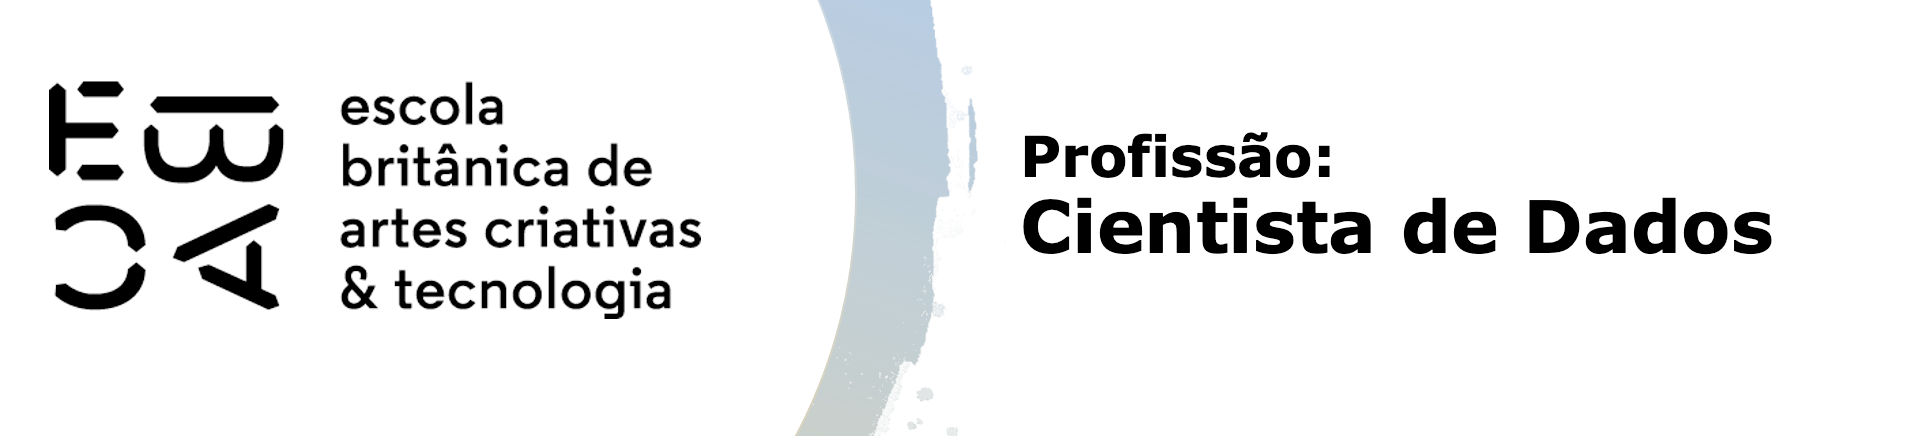

# Tarefa

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?" 

Nosso objetivo é tentar agrupar os clientes conforme seu comportamento de navegação entre páginas administrativas, informativas e de produtos. 

As variáveis estão descritas abaixo (em tradução livre do link indicado).

Por este motivo, o escopo desta análise estará fechado nas primeiras seis variáveis da tabela, referentes a quantidade e tempo de acesso por tipo de página, atributos que falam mais do comportamento de navegação do cliente que de características da página o da época do ano.

|Variavel                |Descrição          | 
|------------------------|:-------------------| 
|Administrative          | Quantidade de acessos em páginas administrativas| 
|Administrative_Duration | Tempo de acesso em páginas administrativas | 
|Informational           | Quantidade de acessos em páginas informativas  | 
|Informational_Duration  | Tempo de acesso em páginas informativas  | 
|ProductRelated          | Quantidade de acessos em páginas de produtos | 
|ProductRelated_Duration | Tempo de acesso em páginas de produtos | 
|BounceRates             | *Percentual de visitantes que entram no site e saem sem acionar outros *requests* durante a sessão  | 
|ExitRates               | * Soma de vezes que a página é visualizada por último em uma sessão dividido pelo total de visualizações | 
|PageValues              | * Representa o valor médio de uma página da Web que um usuário visitou antes de concluir uma transação de comércio eletrônico | 
|SpecialDay              | Indica a proximidade a uma data festiva (dia das mães etc) | 
|Month                   | Mês  | 
|OperatingSystems        | Sistema operacional do visitante | 
|Browser                 | Browser do visitante | 
|Region                  | Região | 
|TrafficType             | Tipo de tráfego                  | 
|VisitorType             | Tipo de visitante: novo ou recorrente | 
|Weekend                 | Indica final de semana | 
|Revenue                 | Indica se houve compra ou não |

\* variávels calculadas pelo google analytics

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from tqdm.notebook import tqdm

In [6]:
df = pd.read_csv('online_shoppers_intention.csv')

In [7]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
df.Revenue.value_counts(dropna=False)

Revenue
False    10422
True      1908
Name: count, dtype: int64

## Análise descritiva

Faça uma análise descritiva das variáveis do escopo.

- Verifique a distribuição dessas variáveis
- Veja se há valores *missing* e caso haja, decida o que fazer
- Faça mais algum tratamento nas variáveis caso ache pertinente

In [10]:
df_escopo = df [['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']]
df_escopo.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
0,0,0.0,0,0.0,1,0.000000
1,0,0.0,0,0.0,2,64.000000
2,0,0.0,0,0.0,1,0.000000
3,0,0.0,0,0.0,2,2.666667
4,0,0.0,0,0.0,10,627.500000


In [11]:
df_escopo.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
dtype: int64

Precisa padronizar os dados

In [13]:
colunas = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']

padronizador = StandardScaler()
dados_padronizado = padronizador.fit_transform(df_escopo)
df_padronizado = pd.DataFrame(dados_padronizado, columns = colunas)
df_padronizado.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430


C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

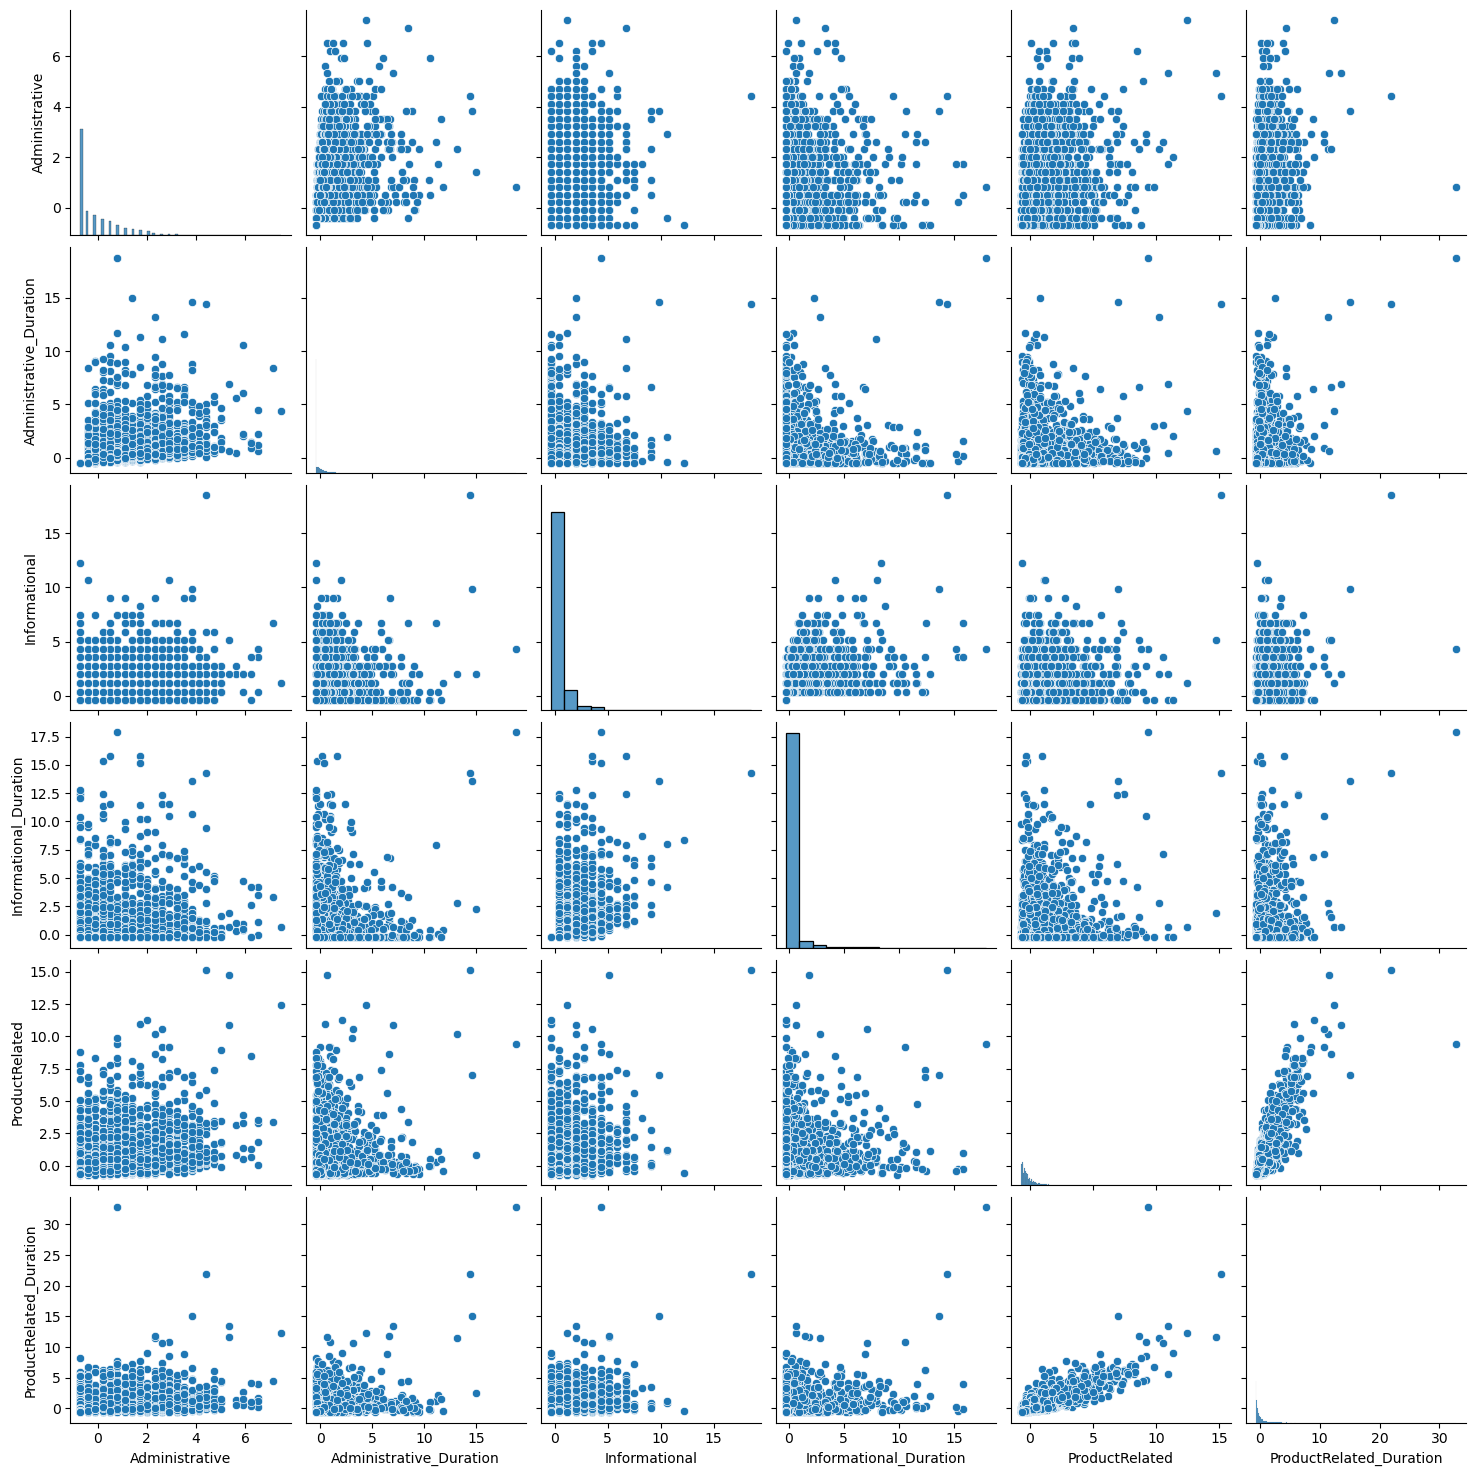

In [14]:
sns.pairplot(df_padronizado)

Observando os dados assim não é possível identificar diferentes grupos de dados justamente por todos os pontos estarem muito próximos e serem todos da mesma cor.

Utilizando o k-means nós poderiamos criar grupos que classificariam os dados de acordo com suas características em comum e assim poderiamos ver os dados acima coloridos.

Para utilizarmos o Kmeans, precisamos definir o número de clusters (grupos) que queremos criar. Para facilitar a nossa escolha podemos criar uma lista e assim verificar qual quantidade de grupos se sai melhor.

## Número de grupos

Utilize as técnicas vistas em aula que te ajudem a decidir pelo número de grupos a ser utilizados.

### Método do cotovelo

In [18]:
SQD = []
K = range(1,15)
for k in tqdm(K):
    km = KMeans(n_clusters=k)
    km = km.fit(df_padronizado)
    SQD.append(km.inertia_)
SQD

  0%|          | 0/14 [00:00<?, ?it/s]

[73980.00000000003,
 51210.55819891579,
 43201.87548354826,
 37464.13917246456,
 33640.631079824685,
 30066.2284167849,
 26738.175448134738,
 24619.567132340635,
 22700.79086882041,
 21048.920806022437,
 19722.388115659465,
 19005.04616594273,
 18129.860599035947,
 17570.453278951936]

<Axes: xlabel='num_clusters'>

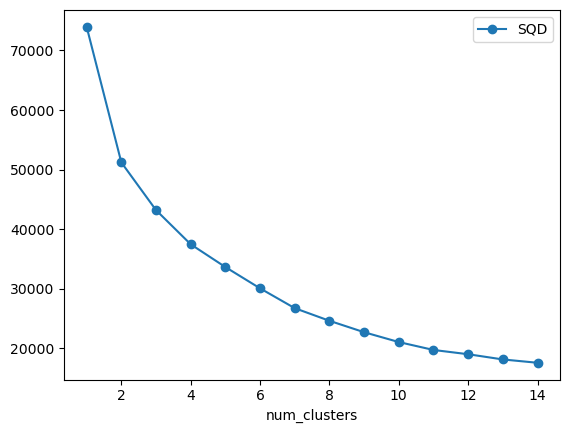

In [19]:
df_graf = pd.DataFrame({'num_clusters': list(range(1, len(SQD)+1)), 'SQD': SQD})
df_graf.plot(x='num_clusters', y='SQD', marker='o')

### Coeficiente de Silueta

In [21]:
%%time
# Inicializar uma lista vazia que vai conter os valores da silueta média
siluetas = []
# Este é o número máximo de grupos que vamos testar
max_clusters = 10

for n_clusters in tqdm(range(2, max_clusters+1)):
    # Aqui rodamos o k-means
    km = KMeans(n_clusters=n_clusters).fit(df_padronizado[colunas])
    # Aqui calculamos a silueta e guardamos o resultado na lista 'siluetas'
    siluetas.append(silhouette_score(df_padronizado[colunas], km.labels_))
    # Essa list comprehendion define o nome dos grupos
    nomes_grupos = ['grupo_' + str(g) for g in range(n_clusters)]
    # Agora vamos adicionar uma coluna no dataframe X_pad com o agrupamento construido
    df_padronizado['grupos_'+str(n_clusters)] = pd.Categorical.from_codes(km.labels_, categories = nomes_grupos)
    
df_padronizado.head()

  0%|          | 0/9 [00:00<?, ?it/s]

CPU times: total: 23.5 s
Wall time: 12.5 s


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,grupos_2,grupos_3,grupos_4,grupos_5,grupos_6,grupos_7,grupos_8,grupos_9,grupos_10
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6


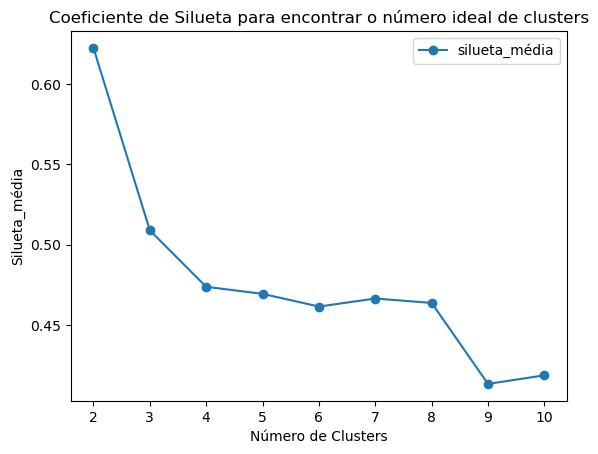

In [22]:
df_silueta = pd.DataFrame({'n_clusters': list(range(2, max_clusters+1)), 'silueta_média': siluetas})
df_silueta.plot.line(x = 'n_clusters', y = 'silueta_média', marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Silueta_média')
plt.title('Coeficiente de Silueta para encontrar o número ideal de clusters')
plt.show();


Após análise dos gráficos do método do cotovelo e do coeficiente de silhueta, notamos que o melhor número de clusters seria 2. No entanto, dependendo do negócio, 3 clusters também poderiam ser interessantes. Visto isso, iremos testar essas hipóteses e ver qual se encaixa melhor.

## Avaliação dos grupos

Faça uma análise descritiva para pelo menos duas soluções de agrupamentos (duas quantidades diferentes de grupos) sugeridas no item anterior, utilizando as variáveis que estão no escopo do agrupamento.
- Com base nesta análise e nas análises anteriores, decida pelo agrupamento final. 
- Se puder, sugira nomes para os grupos.

Incluiremos a variável resposta para plotar gráficos comparativos que nos ajudarão a escolher o número de clusters mais indicado.

In [26]:
df_padronizado['Revenue'] = df['Revenue']
df_padronizado

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,grupos_2,grupos_3,grupos_4,grupos_5,grupos_6,grupos_7,grupos_8,grupos_9,grupos_10,Revenue
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,0.206173,0.363075,-0.396478,-0.244931,0.478227,0.307822,grupo_1,grupo_0,grupo_0,grupo_1,grupo_2,grupo_3,grupo_2,grupo_1,grupo_7,False
12326,-0.696993,-0.457191,-0.396478,-0.244931,-0.601062,-0.380957,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False
12327,-0.696993,-0.457191,-0.396478,-0.244931,-0.578577,-0.528063,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False
12328,0.507228,-0.032916,-0.396478,-0.244931,-0.376210,-0.443536,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_3,grupo_0,grupo_1,grupo_7,False


### 2 clusters

C:\Users\gusta\AppData\Local\Temp\ipykernel_9640\821988018.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df_padronizado.groupby(['grupos_2', 'Revenue'])['Revenue'].count().unstack().plot.bar()


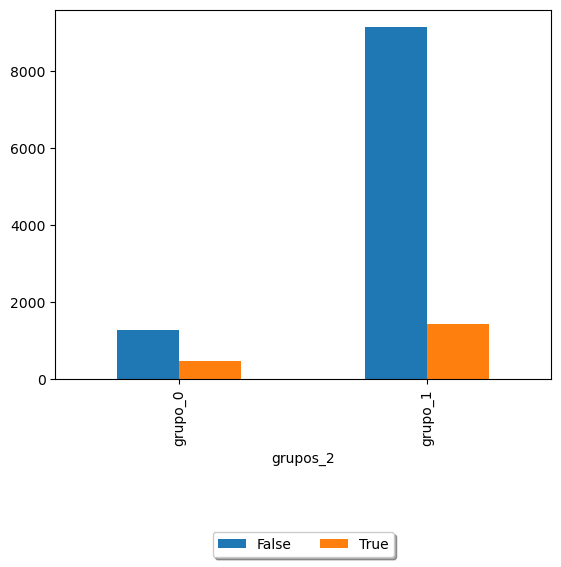

In [28]:
ax = df_padronizado.groupby(['grupos_2', 'Revenue'])['Revenue'].count().unstack().plot.bar()

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -.5),
          ncol=3, fancybox=True, shadow=True);

C:\Users\gusta\AppData\Local\Temp\ipykernel_9640\3110062091.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax.plot(df_padronizado.groupby(['grupos_2'])[colunas].mean().apply(padroniza), 'o ')


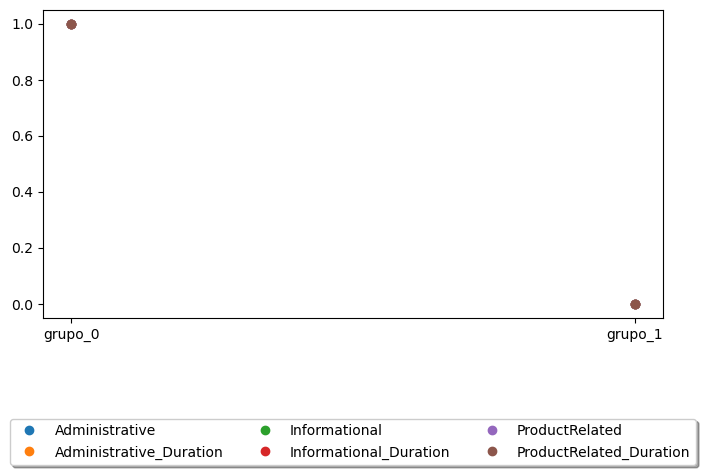

In [29]:
padroniza = lambda x: (x - x.min())/(x.max() - x.min())

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_padronizado.groupby(['grupos_2'])[colunas].mean().apply(padroniza), 'o ')
ax.legend(colunas, loc='lower center', bbox_to_anchor=(0.5, -.5),
          ncol=3, fancybox=True, shadow=True)

In [30]:
pd.crosstab(df_padronizado['Revenue'], df_padronizado['grupos_2'])

grupos_2,grupo_0,grupo_1
Revenue,,
False,1273,9149
True,479,1429


In [31]:
pd.crosstab(df_padronizado['Revenue'], df_padronizado['grupos_2'], normalize='columns')

grupos_2,grupo_0,grupo_1
Revenue,,
False,0.726598,0.864908
True,0.273402,0.135092


C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and 

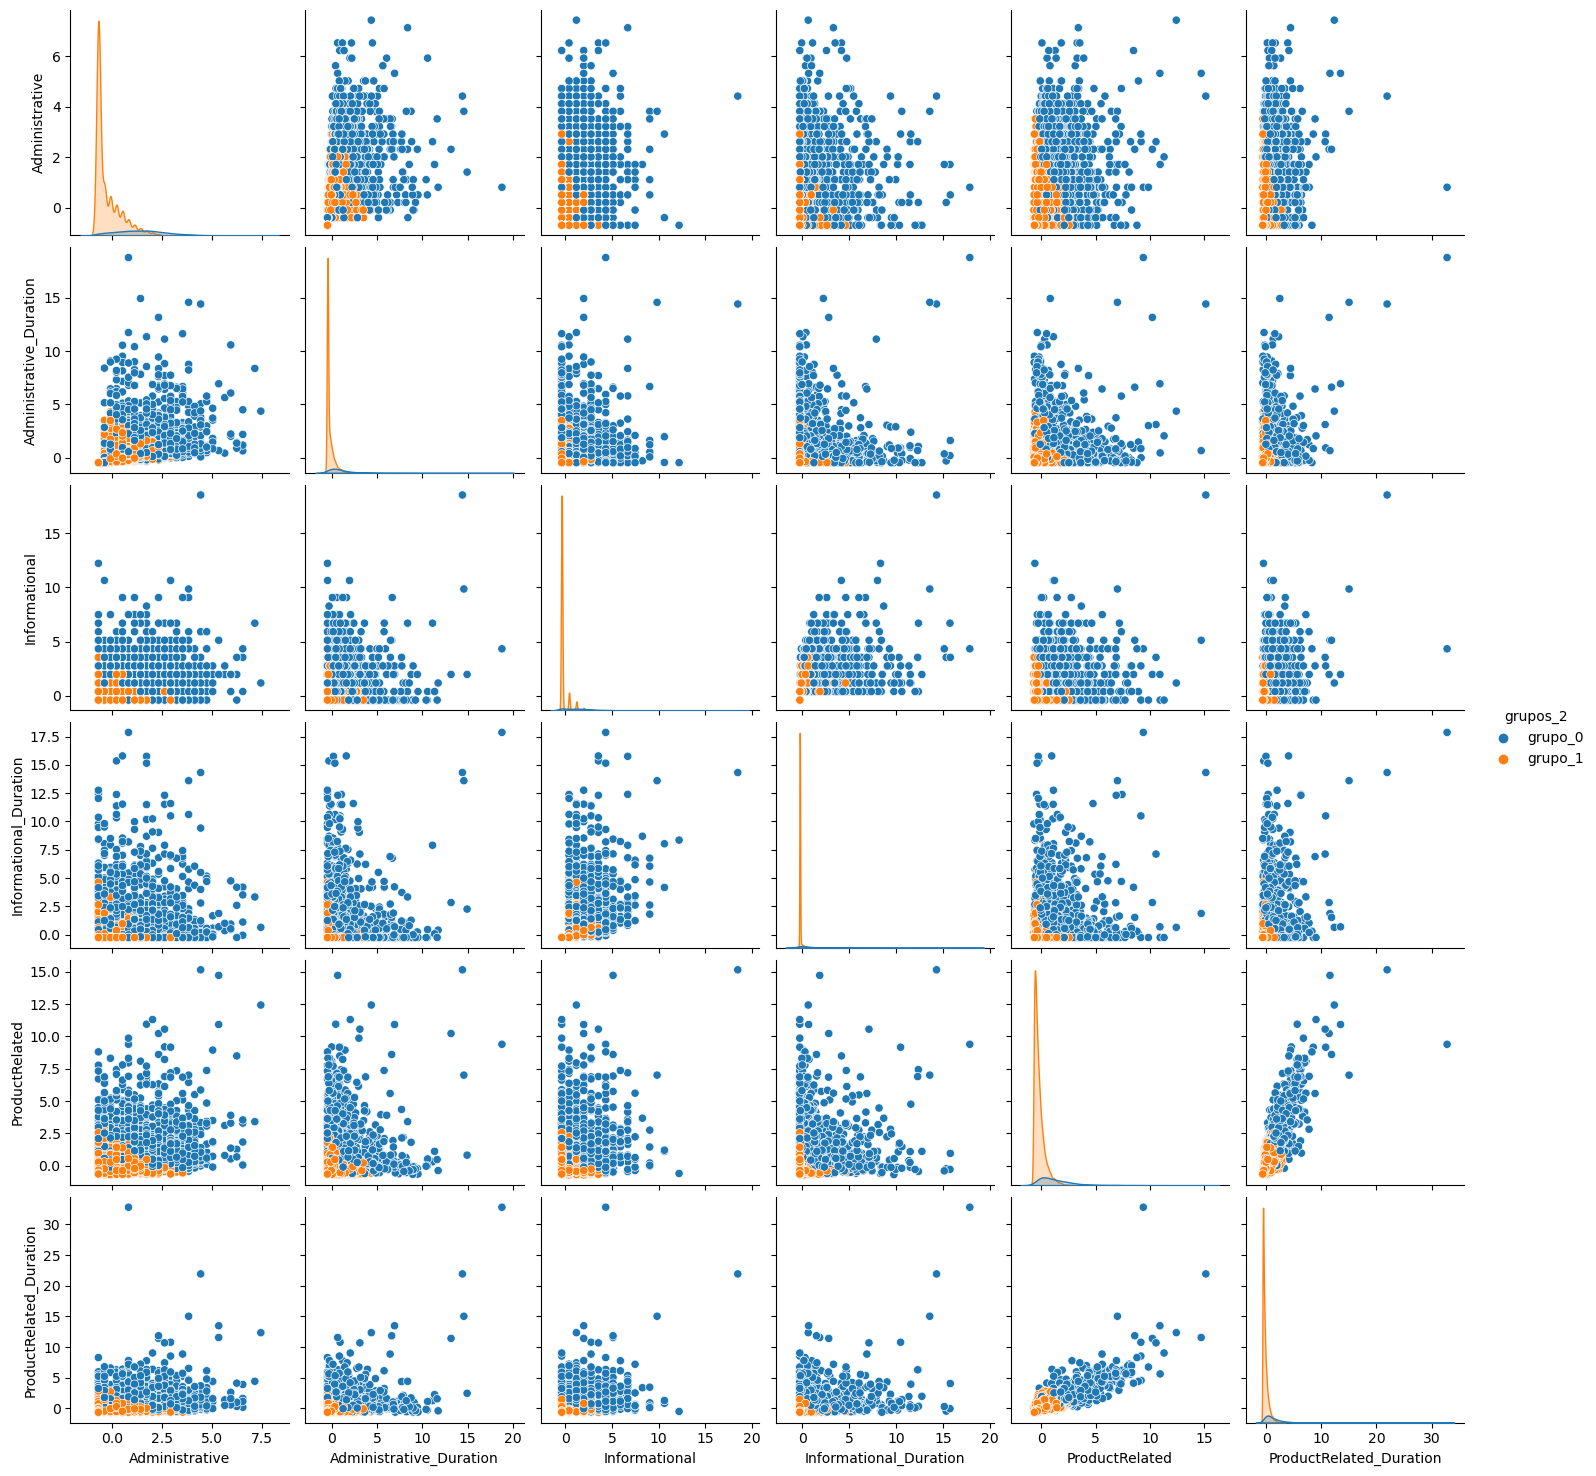

In [32]:
n_clusters = 2
var_grupo = 'grupos_' + str(n_clusters)
sns.pairplot(df_padronizado[colunas + [var_grupo]], hue=var_grupo)

### 3 clusters

C:\Users\gusta\AppData\Local\Temp\ipykernel_9640\2537557241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax = df_padronizado.groupby(['grupos_3', 'Revenue'])['Revenue'].count().unstack().plot.bar()


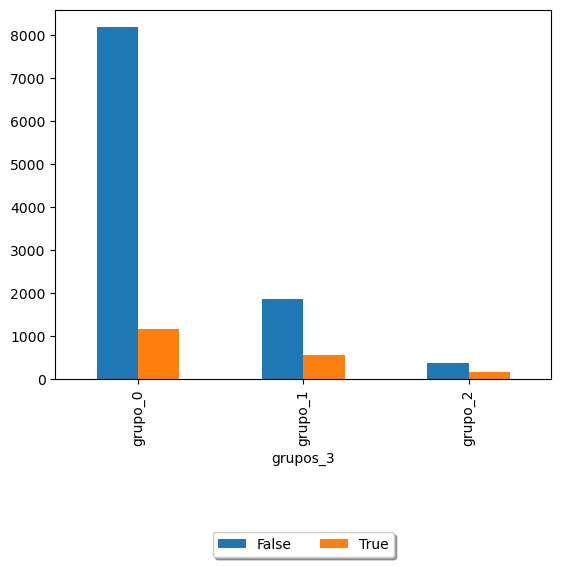

In [34]:
ax = df_padronizado.groupby(['grupos_3', 'Revenue'])['Revenue'].count().unstack().plot.bar()

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -.5),
          ncol=3, fancybox=True, shadow=True);

C:\Users\gusta\AppData\Local\Temp\ipykernel_9640\1339029984.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ax.plot(df_padronizado.groupby(['grupos_3'])[colunas].mean().apply(padroniza), 'o ')


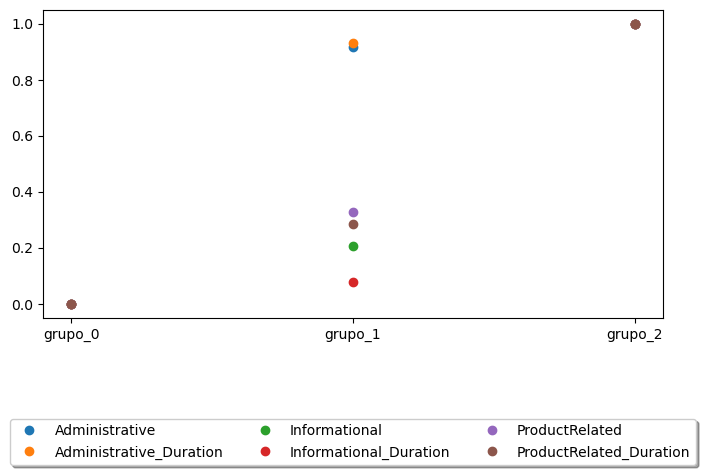

In [35]:
padroniza = lambda x: (x - x.min())/(x.max() - x.min())

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_padronizado.groupby(['grupos_3'])[colunas].mean().apply(padroniza), 'o ')
ax.legend(colunas, loc='lower center', bbox_to_anchor=(0.5, -.5),
          ncol=3, fancybox=True, shadow=True)

In [36]:
pd.crosstab(df_padronizado['Revenue'], df_padronizado['grupos_3'])

grupos_3,grupo_0,grupo_1,grupo_2
Revenue,,,
False,8174,1871,377
True,1172,572,164


In [37]:
pd.crosstab(df_padronizado['Revenue'], df_padronizado['grupos_3'], normalize='columns')

grupos_3,grupo_0,grupo_1,grupo_2
Revenue,,,
False,0.874599,0.765862,0.696858
True,0.125401,0.234138,0.303142


C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and 

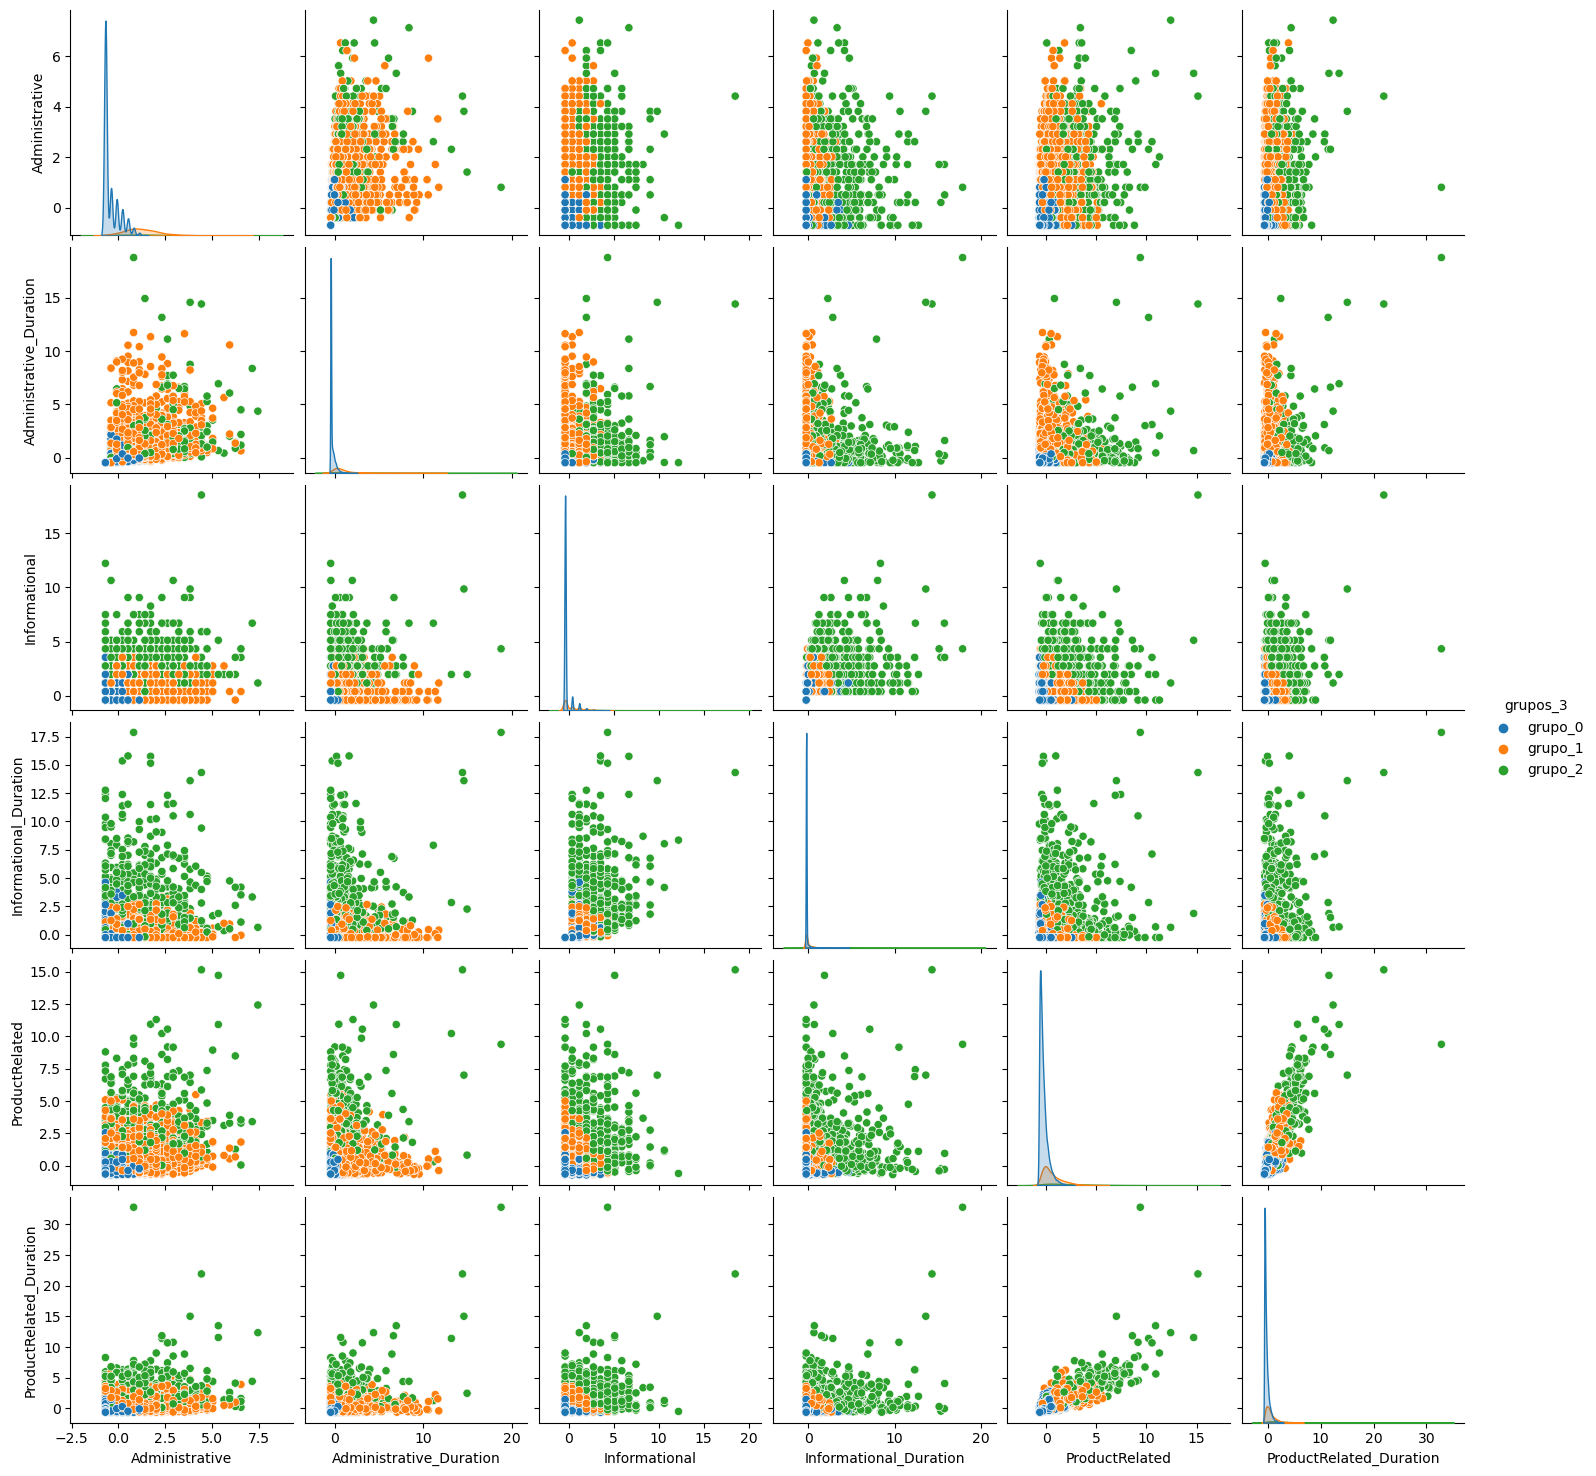

In [38]:
n_clusters = 3
var_grupo = 'grupos_' + str(n_clusters)
sns.pairplot(df_padronizado[colunas + [var_grupo]], hue=var_grupo)

## Avaliação de resultados

Avalie os grupos obtidos com relação às variáveis fora do escopo da análise (minimamente *bounce rate* e *revenue*). 
- Qual grupo possui clientes mais propensos à compra?

In [40]:
df_padronizado['BounceRates'] = df['BounceRates']
df_padronizado.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,grupos_2,grupos_3,grupos_4,grupos_5,grupos_6,grupos_7,grupos_8,grupos_9,grupos_10,Revenue,BounceRates
12325,0.206173,0.363075,-0.396478,-0.244931,0.478227,0.307822,grupo_1,grupo_0,grupo_0,grupo_1,grupo_2,grupo_3,grupo_2,grupo_1,grupo_7,False,0.007143
12326,-0.696993,-0.457191,-0.396478,-0.244931,-0.601062,-0.380957,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False,0.000000
12327,-0.696993,-0.457191,-0.396478,-0.244931,-0.578577,-0.528063,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False,0.083333
12328,0.507228,-0.032916,-0.396478,-0.244931,-0.376210,-0.443536,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_3,grupo_0,grupo_1,grupo_7,False,0.000000
12329,-0.696993,-0.457191,-0.396478,-0.244931,-0.646033,-0.613243,grupo_1,grupo_0,grupo_2,grupo_3,grupo_0,grupo_0,grupo_0,grupo_6,grupo_6,False,0.000000


C:\Users\gusta\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='BounceRates', ylabel='grupos_3'>

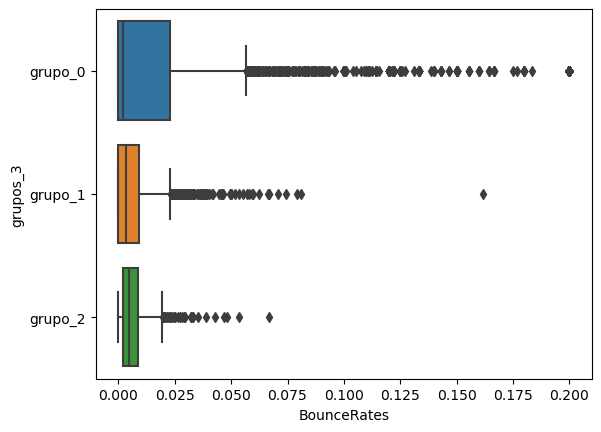

In [41]:
sns.boxplot(data=df_padronizado, y='grupos_3', x='BounceRates')

In [42]:
pd.crosstab(df_padronizado['Revenue'], df_padronizado['grupos_3'])

grupos_3,grupo_0,grupo_1,grupo_2
Revenue,,,
False,8174,1871,377
True,1172,572,164


In [43]:
pd.crosstab(df_padronizado['Revenue'], df_padronizado['grupos_3'], normalize='columns')

grupos_3,grupo_0,grupo_1,grupo_2
Revenue,,,
False,0.874599,0.765862,0.696858
True,0.125401,0.234138,0.303142


A análise de segmentação dos usuários, utilizando agrupamento em 3 clusters, permitiu identificar que o grupo_2 concentra os clientes mais propensos à realizar compras. Esse grupo apresentou a maior proporção de usuários com comportamento compatível com compra, além de registrar o menor percentual de visitantes que acessam o site e saem sem realizar nenhuma outra interação durante a sessão. Esses indicadores sugerem que os usuários do grupo_2 são mais engajados e representam o público com maior potencial de gerar receita, sendo, portanto, o principal foco para estratégias de marketing e otimização da jornada do cliente.